# Regression Model Comparison
Submission-ready notebook.

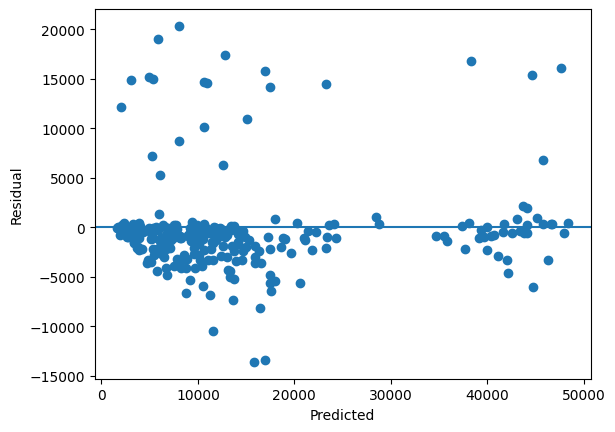

              Model          MAE         RMSE        R2     CV R2
7  GradientBoosting  2493.387976  4247.122850  0.901837  0.853893
1        Polynomial  2867.317439  4646.056793  0.882530  0.835054
6      RandomForest  2636.934370  4700.637003  0.879754  0.834108
5      DecisionTree  2729.486090  5768.968106  0.818885  0.697842
0            Linear  4177.045561  5956.342894  0.806929  0.741750
3             Lasso  4177.130422  5956.451557  0.806922  0.741751
2             Ridge  4194.009577  5971.338292  0.805955  0.741832
4        ElasticNet  4972.931303  6932.655987  0.738448  0.709293


In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RepeatedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

df=pd.read_csv('insurance.csv')

df=df.drop_duplicates()
X=df.drop('charges',axis=1); y=df['charges']
cat=['sex','smoker','region']

prep=ColumnTransformer([('cat',OneHotEncoder(drop='first'),cat)],remainder='passthrough')
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

models={
'Linear':LinearRegression(),
'Polynomial':Pipeline([('prep',prep),('poly',PolynomialFeatures(2,include_bias=False)),('model',LinearRegression())]),
'Ridge':Ridge(),
'Lasso':Lasso(alpha=0.1),
'ElasticNet':ElasticNet(alpha=0.1,l1_ratio=0.5),
'DecisionTree':DecisionTreeRegressor(random_state=42),
'RandomForest':RandomForestRegressor(random_state=42),
'GradientBoosting':GradientBoostingRegressor(random_state=42)}

rows=[]
for n,m in models.items():
    if n=='Polynomial': pipe=m
    else: pipe=Pipeline([('prep',prep),('model',m)])
    pipe.fit(X_train,y_train)
    p=pipe.predict(X_test)
    mae=mean_absolute_error(y_test,p); mse=mean_squared_error(y_test,p); rmse=np.sqrt(mse); r2=r2_score(y_test,p)
    cv=cross_val_score(pipe,X,y,cv=RepeatedKFold(n_splits=5,n_repeats=2,random_state=42),scoring='r2').mean()
    rows.append([n,mae,rmse,r2,cv])
    if n=='RandomForest':
        res=y_test-p
        plt.scatter(p,res); plt.axhline(0); plt.xlabel('Predicted'); plt.ylabel('Residual'); plt.show()

print(pd.DataFrame(rows,columns=['Model','MAE','RMSE','R2','CV R2']).sort_values('R2',ascending=False))